In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Implementation of Multilayer Perceptrons

Multilayer perceptrons (MLPs) are not much more complex to implement than simple linear models. The key conceptual
difference is that we now concatenate multiple layers.

In [1]:
from d2l import jax as d2l
from flax import nnx
from jax import numpy as jnp

## Implementation from Scratch

Let's begin again by implementing such a network from scratch.

### Initializing Model Parameters

Recall that Fashion-MNIST contains 10 classes,
and that each image consists of a $28 \times 28 = 784$
grid of grayscale pixel values.
As before we will disregard the spatial structure
among the pixels for now,
so we can think of this as a classification dataset
with 784 input features and 10 classes.
To begin, we will implement an MLP
with one hidden layer and 256 hidden units
(the figure).
Both the number of layers and their width are adjustable
(they are considered hyperparameters).
Typically, we choose each layer width to be a power of 2, which is efficient
for hardware memory addressing.

![The two-layer MLP of this section: a batched input is flattened to 784 features, mapped by an affine layer to a 256-dimensional hidden representation, passed through a ReLU, then mapped by a second affine layer to 10 logits.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-mlp-arch.svg)

Again, we will represent our parameters with several tensors.
Note that *for every layer*, we must keep track of
one weight matrix and one bias vector.
As always, we allocate memory
for the gradients of the loss with respect to these parameters.
We use small Gaussian noise ($\sigma = 0.01$) as a simple starting point;
principled strategies for choosing this scale are the subject of
that section.

In the code below, `nnx.Param` marks each array as a trainable parameter.

In [2]:
class MLPScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, num_hiddens, lr,
                 sigma=0.01, rngs=None):
        super().__init__()
        self.save_hyperparameters(ignore=['rngs'])
        rngs = nnx.Rngs(d2l.get_key()) if rngs is None else rngs
        self.W1 = nnx.Param(
            rngs.params.normal((num_inputs, num_hiddens)) * sigma)
        self.b1 = nnx.Param(jnp.zeros(num_hiddens))
        self.W2 = nnx.Param(
            rngs.params.normal((num_hiddens, num_outputs)) * sigma)
        self.b2 = nnx.Param(jnp.zeros(num_outputs))

### Model

To make sure we know how everything works,
we will implement the ReLU activation ourselves
rather than invoking the built-in `relu` function directly.

In [3]:
def relu(X):
    return jnp.maximum(X, 0)

Since we are disregarding spatial structure,
we `reshape` each two-dimensional image into
a flat vector of length  `num_inputs`.
Finally, we implement our model
with just a few lines of code. Since autograd handles the backward pass, this is all that it takes.

In [4]:
@d2l.add_to_class(MLPScratch)
def forward(self, X):
    X = d2l.reshape(X, (-1, self.num_inputs))
    H = relu(d2l.matmul(X, self.W1) + self.b1)
    return d2l.matmul(H, self.W2) + self.b2

### Training

Fortunately, the training loop for MLPs
is exactly the same as for softmax regression. We define the model, data, and trainer, then finally invoke the `fit` method on model and data.

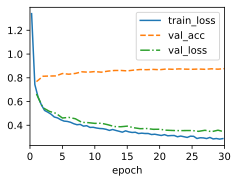

In [5]:
model = MLPScratch(num_inputs=784, num_outputs=10, num_hiddens=256, lr=0.1)
data = d2l.FashionMNIST(batch_size=256)
trainer = d2l.Trainer(max_epochs=30)
trainer.fit(model, data)

You should see the validation accuracy settle at typically around $0.87$, a
modest improvement over the softmax regression baseline of
that section on the same data, bought by the hidden layer and
its ReLU.

## Concise Implementation

As you might expect, by relying on the high-level APIs, we can implement MLPs even more concisely.

### Model

Compared with our concise implementation
of softmax regression
(that section),
the only difference is that we add
*two* fully connected layers where we previously added only *one*.
The first is the hidden layer,
the second is the output layer.

In [6]:
class MLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens, lr, num_inputs=784,
                 rngs=None):
        super().__init__()
        self.save_hyperparameters(ignore=['rngs'])
        rngs = nnx.Rngs(d2l.get_key()) if rngs is None else rngs
        self.hidden = nnx.Linear(num_inputs, num_hiddens, rngs=rngs)
        self.output = nnx.Linear(num_hiddens, num_outputs, rngs=rngs)

    def forward(self, X):
        X = X.reshape((X.shape[0], -1))  # Flatten
        return self.output(nnx.relu(self.hidden(X)))

Previously, we defined `forward` methods for models to transform input using the model parameters.
These operations are essentially a pipeline:
you take an input and
apply a transformation (e.g.,
matrix multiplication with weights followed by bias addition),
then repetitively use the output of the current transformation as
input to the next transformation.
However, you may have noticed that 
no `forward` method is defined here.
In fact, `MLP` inherits the `forward` method from the `Module` class (that section) to 
simply invoke `self.net(X)` (`X` is input),
which is now defined as a sequence of transformations
via the `Sequential` class.
The `Sequential` class abstracts the forward process
enabling us to focus on the transformations.
We will further discuss how the `Sequential` class works in that section.


### Training

The training loop is exactly the same
as when we implemented softmax regression.
This modularity enables us to separate
matters concerning the model architecture
from orthogonal considerations.
Note that while the two versions compute the same *architecture*, they do not
start from the same *parameters*: the scratch model draws its weights from
$\mathcal{N}(0, 0.01^2)$, whereas the concise version uses the library's
default initializer. Defaults differ across libraries and layer types, so the
two versions need not start at comparable scales. Their training trajectories
and final accuracies can therefore differ.

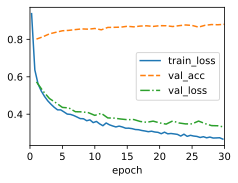

In [7]:
model = MLP(num_outputs=10, num_hiddens=256, lr=0.1)
trainer.fit(model, data)

## Summary

We have now built and trained a working multilayer perceptron, a network with a hidden layer and a nonlinearity, in both a from-scratch and a concise form. The from-scratch version makes the new ingredients concrete: two weight matrices, two bias vectors, a hand-rolled ReLU, and a two-step forward computation. The concise version shows that `nn.Sequential` collapses all of that into a four-element stack. The training loop, the loss function, and the data loader are unchanged from softmax regression, a benefit of the modular design.

The from-scratch version also exposes why we reach for the high-level API: naming and tracking parameters by hand quickly becomes awkward. Imagine inserting another layer between layers 42 and 43; we would be stuck renaming or improvising a "layer 42b". `nn.Sequential` removes both problems at once.

Three questions remain open, and each is the subject of one of the next sections:

* **How do gradients flow through this stack, and what can go wrong as it gets deeper?** (that section, that section)
* **Why does such a flexible model generalize to unseen data at all?** (that section)
* **How can we regularize it to generalize better?** (that section)

Answering them turns this small working model into a reliable building block.


## Exercises

1. Change the number of hidden units `num_hiddens` and plot how its number affects the accuracy of the model. What is the best value of this hyperparameter?
1. Try adding a hidden layer to see how it affects the results. In particular, add one to the *from-scratch* model while keeping its $\sigma = 0.01$ Gaussian initialization: you may find that the deeper network trains *worse*. Why that happens, and what to do about it, is the subject of that section.
1. Why is it a bad idea to insert a hidden layer with a single neuron? What could go wrong?
1. How does changing the learning rate alter your results? With all other parameters fixed, which learning rate gives you the best results? How does this relate to the number of epochs?
1. Let's optimize over all hyperparameters jointly, i.e., learning rate, number of epochs, number of hidden layers, and number of hidden units per layer.
    1. What is the best result you can get by optimizing over all of them?
    1. Why it is much more challenging to deal with multiple hyperparameters?
    1. Describe an efficient strategy for optimizing over multiple parameters jointly.
1. Compare the speed of the framework and the from-scratch implementation for a challenging problem. How does it change with the complexity of the network?
1. Measure the speed of tensor--matrix multiplications for well-aligned and misaligned matrices. For instance, test for matrices with dimension 1024, 1025, 1026, 1028, and 1032.
    1. How does this change between GPUs and CPUs?
    1. Determine the memory bus width of your CPU and GPU.
1. Try out different activation functions. Which one works best on Fashion-MNIST? Compare at least ReLU, tanh, sigmoid, and GELU (`torch.nn.functional.gelu` in PyTorch, `jax.nn.gelu` in JAX). (*Hint:* for sigmoid and tanh you may need to retune the learning rate.) GELU is used in BERT and GPT-2-style Transformers, while many recent language models use gated SiLU/SwiGLU blocks. Does this small image task provide enough evidence to choose among them for a Transformer?
1. Compare the effect of three initialization scales on training: (a) small Gaussian noise with $\sigma = 0.001$; (b) the value used in this section, $\sigma = 0.01$; (c) large Gaussian noise with $\sigma = 0.1$. Plot the training and validation curves for each. Why does $\sigma$ matter? (*Hint:* consider what happens to the activations on the very first forward pass.) The principled answer is developed in that section.

[Discussions](https://d2l.discourse.group/t/17985)